# Gaussian Approximation Analysis
As $\nu \to \infty$, at what point can our robust and non-linear SSM be approximated as a linear Gaussian and therefore be best estimated by the Kalman filter?

We have **two independent** degrees-of-freedom parameters:

- **State innovations:** $\eta_t \sim \text{SubGaussian}(0, w; \nu_\eta)$  

- **Observation noise:** $e_t \sim t(0, \sigma; \nu_\varepsilon)$  

As degrees of freedom increase:
- Sub-Gaussian's light tails for state innovations start light and the tails fill out to approach Gaussian
- The t-distributed observation noise starts with fat tails which are reduced to a Gaussian

In [1]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from dataclasses import replace
import robust_ssm as ss

### Convergence of both distributions


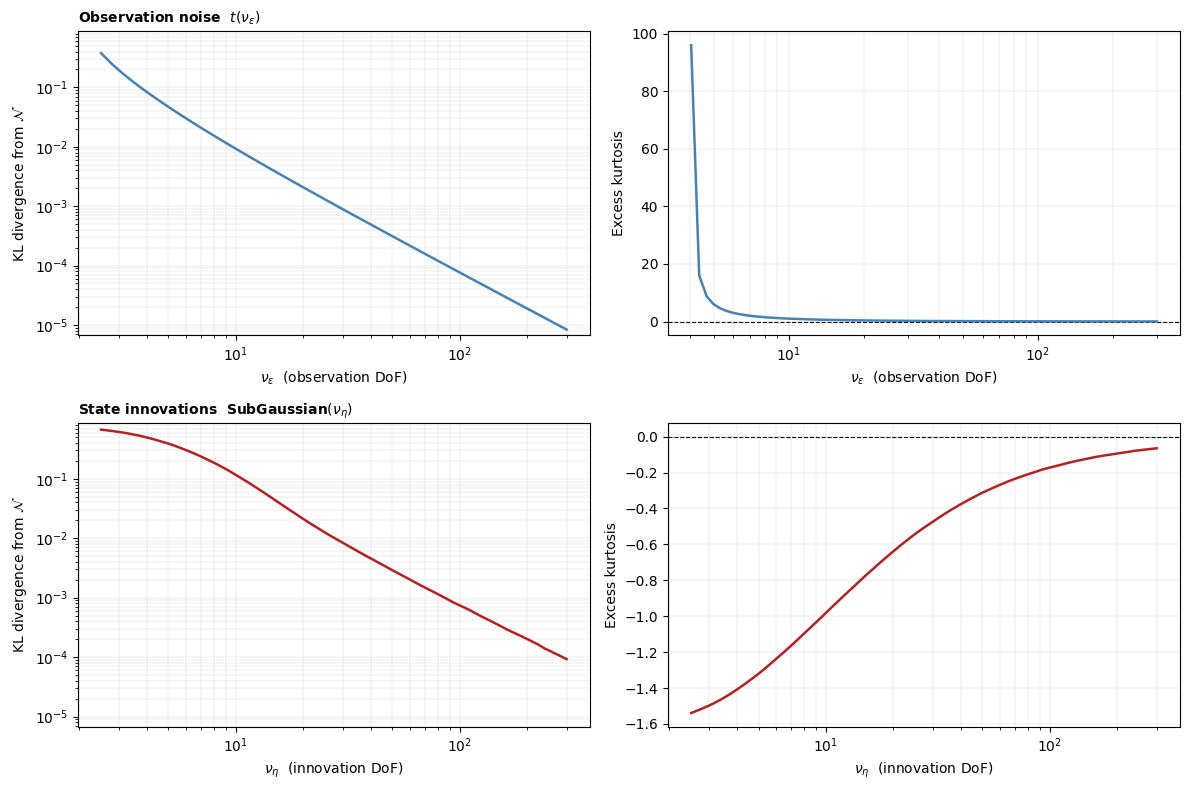

In [ ]:
fig = ss.plot_gaussian_approx_combined(w=1.0)
fig.savefig('./figs/gaussian_approx_combined.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close('all')

### Vary $\nu_\varepsilon$ (observation df), hold $\nu_\eta = 300$

In [7]:
print("Running: vary nu_eps, fix nu_eta=8...")
nu_eps_sweep = np.unique(np.concatenate([
    np.linspace(2.5, 10.0, 12),
    np.linspace(10.0, 50.0, 12),
    np.linspace(50.0, 300.0, 10),
]))

results_eps = ss.run_gaussian_approx_1d_sweep(
    vary="nu_eps",
    nu_vary_list=list(nu_eps_sweep),
    nu_fixed=8.0,
    p_base=ss.DualNuParams(T=300, N=500, seed=42),
    n_reps=8,
)
print("Done.")

Running: vary nu_eps, fix nu_eta=8...
Done.


### Vary $\nu_\eta$ (innovation df), fix $\nu_\varepsilon = 300$

In [5]:
print("Running 1D sweep: vary nu_eta, fix nu_eps=8...")
nu_eta_sweep = np.unique(np.concatenate([
    np.linspace(2.5, 10.0, 12),
    np.linspace(10.0, 50.0, 12),
    np.linspace(50.0, 300.0, 10),
]))

results_eta = ss.run_gaussian_approx_1d_sweep(
    vary="nu_eta",
    nu_vary_list=list(nu_eta_sweep),
    nu_fixed=8.0,
    p_base=ss.DualNuParams(T=300, N=500, seed=42),
    n_reps=8,
)
print("Done.")

Running 1D sweep: vary nu_eta, fix nu_eps=8...
Done.


### Compare RMSE across 1D sweeps

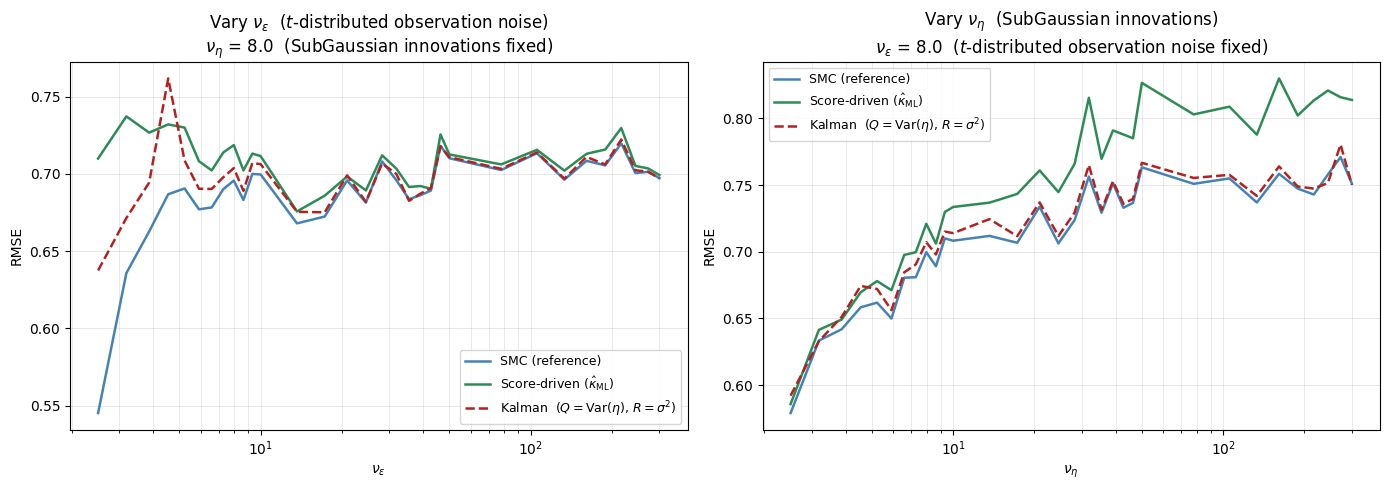

In [8]:
fig = ss.plot_gaussian_approx_1d_sweeps(results_eps, results_eta)
fig.savefig("./figs/gaussian_approx_1d_sweeps.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close("all")

## 2D Heatmap

Grid of $(\nu_\eta, \nu_\varepsilon)$ showing the region where Gaussian approximation (Kalman) is good.

In [7]:
print("Running 2D sweep over (nu_eta, nu_eps) grid...")
nu_2d = [3, 5, 8, 12, 20, 50, 100, 300]

sweep_2d = ss.run_gaussian_approx_2d_sweep(
    nu_eta_list=nu_2d,
    nu_eps_list=nu_2d,
    p_base=ss.DualNuParams(T=300, N=500, seed=42),
    n_reps=20,
    verbose=True,
)
print("Done.")

Running 2D sweep over (nu_eta, nu_eps) grid...
  nu_eta=3 done  (1/8)
  nu_eta=5 done  (2/8)
  nu_eta=8 done  (3/8)
  nu_eta=12 done  (4/8)
  nu_eta=20 done  (5/8)
  nu_eta=50 done  (6/8)
  nu_eta=100 done  (7/8)
  nu_eta=300 done  (8/8)
Done.


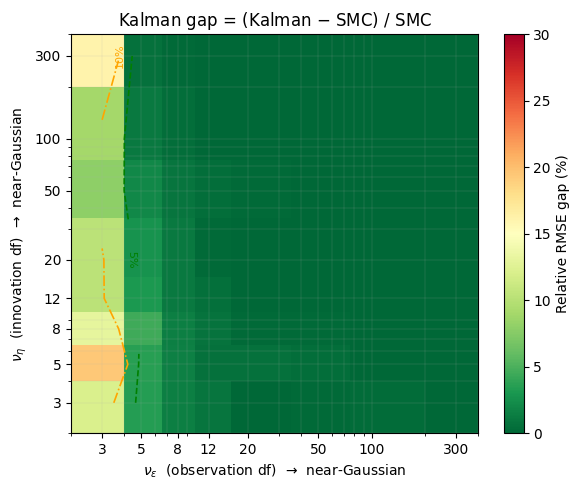

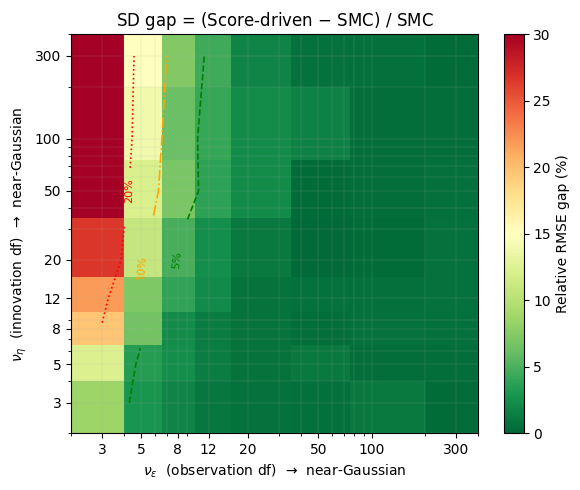

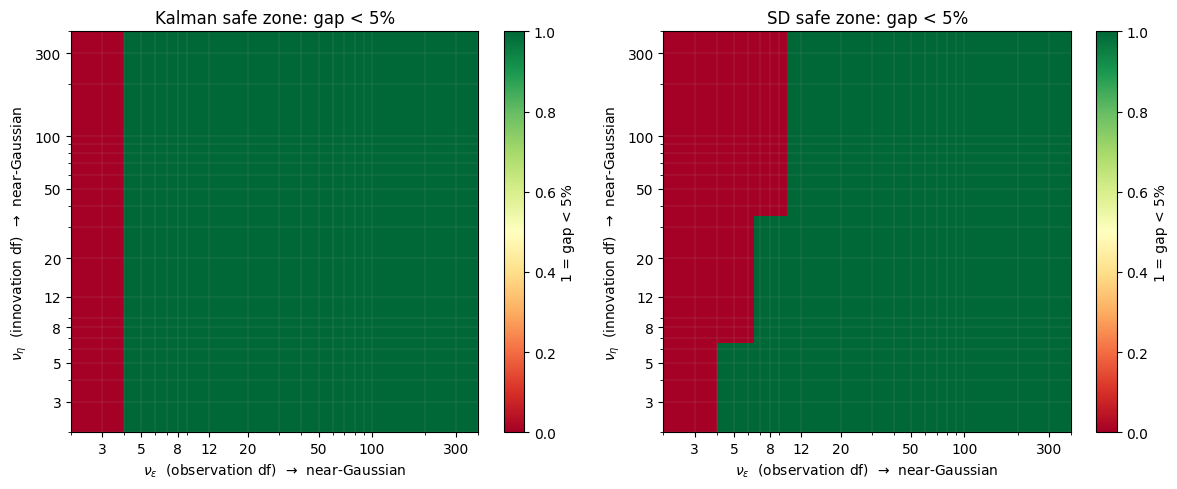

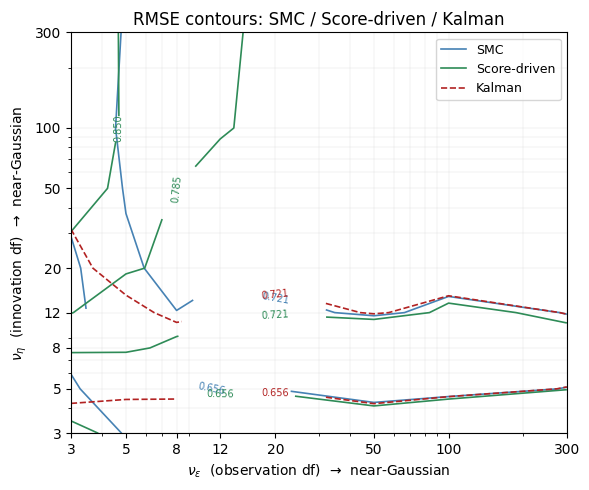

In [8]:
fig1, fig2, fig3, fig4 = ss.plot_gaussian_approx_2d_heatmap(sweep_2d, threshold=0.05)

fig1.savefig("./figs/gaussian_approx_2d_heatmap_kal_gap.png",  dpi=150, bbox_inches="tight")
fig2.savefig("./figs/gaussian_approx_2d_heatmap_sd_gap.png",   dpi=150, bbox_inches="tight")
fig3.savefig("./figs/gaussian_approx_2d_heatmap_safezones.png", dpi=150, bbox_inches="tight")
fig4.savefig("./figs/gaussian_approx_2d_heatmap_contours.png", dpi=150, bbox_inches="tight")

display(fig1); display(fig2); display(fig3); display(fig4)
plt.close("all")

## HPC 2D Heatmap
Aggregates the 64 PBS array job outputs from `run_heatmap_array.pbs`
Each grid point: 100 reps, T=1000, N=500 particles

**Needs to be run on HPC first**

In [ ]:
import os

NU_GRID  = [3, 5, 8, 12, 20, 50, 100, 300]
N_GRID   = len(NU_GRID)
N_TOTAL  = N_GRID ** 2
HPC_DIR  = './figs/heatmap'

rmse_smc = np.full((N_GRID, N_GRID), np.nan)
rmse_sd  = np.full((N_GRID, N_GRID), np.nan)
rmse_kal = np.full((N_GRID, N_GRID), np.nan)

missing = []
for idx in range(N_TOTAL):
    path = f'{HPC_DIR}/heatmap_{idx}.npz'
    if not os.path.exists(path):
        missing.append(idx)
        continue
    d = np.load(path)
    i, j = idx // N_GRID, idx % N_GRID
    rmse_smc[i, j] = float(d['rmse_smc'])
    rmse_sd [i, j] = float(d['rmse_sd'])
    rmse_kal[i, j] = float(d['rmse_kal'])

if missing:
    print(f'WARNING: {len(missing)} grid points missing: {missing}')
else:
    print(f'All {N_TOTAL} grid points loaded.')

rel_gap_sd  = (rmse_sd  - rmse_smc) / rmse_smc
rel_gap_kal = (rmse_kal - rmse_smc) / rmse_smc

sweep_hpc = dict(
    nu_eta_list = NU_GRID,
    nu_eps_list = NU_GRID,
    rmse_smc    = rmse_smc,
    rmse_sd     = rmse_sd,
    rmse_kalman = rmse_kal,
    rel_gap_sd  = rel_gap_sd,
    rel_gap_kal = rel_gap_kal,
)

print('\nKalman gap summary (% above SMC):')
header = '  nu_eta\\nu_eps  ' + '  '.join(f'{v:>5}' for v in NU_GRID)
print(header)
for i, nu_eta in enumerate(NU_GRID):
    row = '  '.join(f'{rel_gap_kal[i,j]*100:5.1f}%' for j in range(N_GRID))
    print(f'  {nu_eta:>5}            {row}')

All 64 grid points loaded.

Kalman gap summary (% above SMC):
  nu_eta\nu_eps      3      5      8     12     20     50    100    300
      3             14.3%    4.0%    1.5%    0.7%    0.4%    0.2%    0.0%    0.0%
      5             13.1%    4.0%    1.6%    0.7%    0.4%    0.2%    0.1%    0.1%
      8             13.1%    3.2%    1.2%    0.6%    0.4%    0.1%    0.1%    0.1%
     12             11.3%    3.3%    1.1%    0.4%    0.2%    0.0%   -0.0%    0.0%
     20             10.4%    2.5%    0.9%    0.3%    0.0%    0.0%   -0.0%   -0.1%
     50             10.1%    2.1%    0.5%    0.1%   -0.1%   -0.2%   -0.2%   -0.2%
    100              9.8%    2.0%    0.2%    0.0%   -0.1%   -0.2%   -0.3%   -0.2%
    300             12.2%    2.1%    0.4%   -0.0%   -0.2%   -0.2%   -0.2%   -0.3%


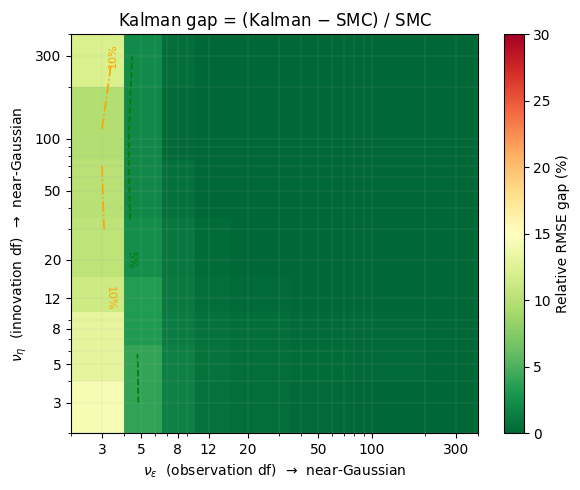

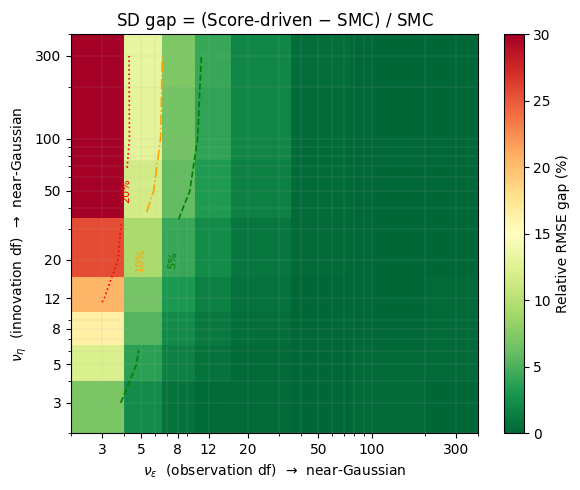

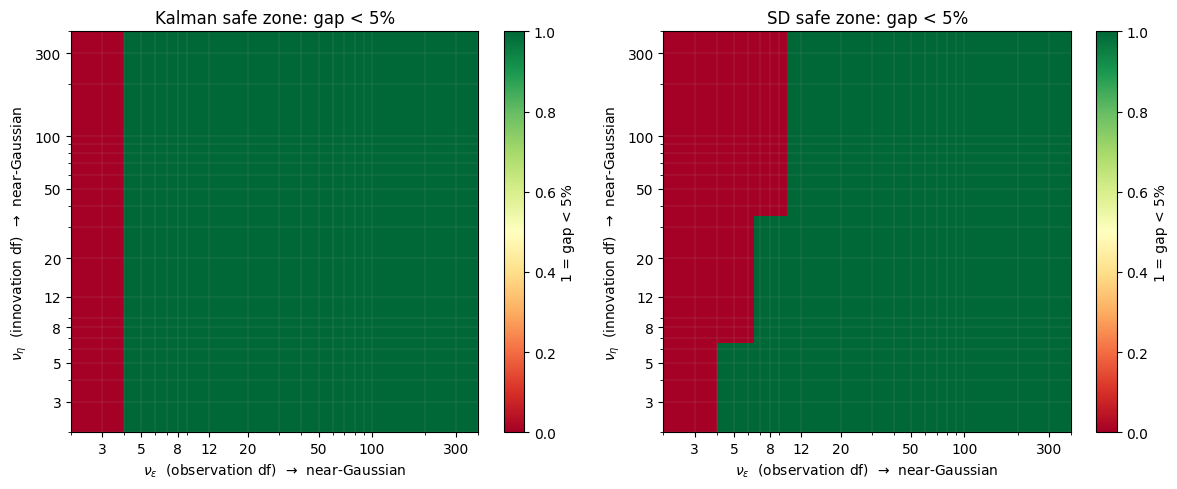

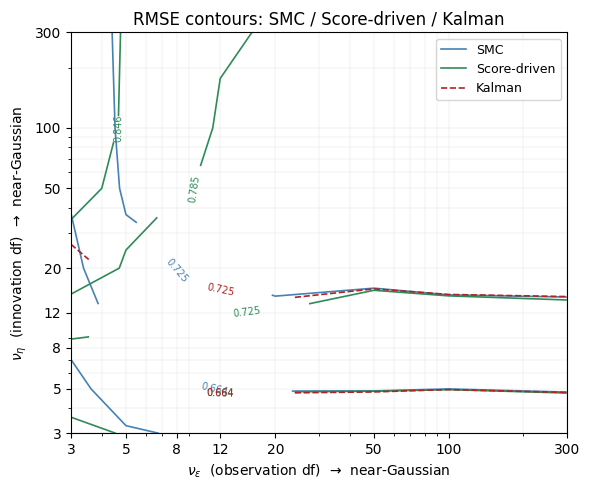

Figures saved to figs/ — ready for the report.


In [10]:
os.makedirs('./results', exist_ok=True)

fig1, fig2, fig3, fig4 = ss.plot_gaussian_approx_2d_heatmap(sweep_hpc, threshold=0.05)

fig1.savefig('./figs/gaussian_approx_2d_heatmap_kal_gap.png',   dpi=150, bbox_inches='tight')
fig2.savefig('./figs/gaussian_approx_2d_heatmap_sd_gap.png',    dpi=150, bbox_inches='tight')
fig3.savefig('./figs/gaussian_approx_2d_heatmap_safezones.png', dpi=150, bbox_inches='tight')
fig4.savefig('./figs/gaussian_approx_2d_heatmap_contours.png',  dpi=150, bbox_inches='tight')

display(fig1); display(fig2); display(fig3); display(fig4)
plt.close('all')
print('Figures saved to figs/ — ready for the report.')

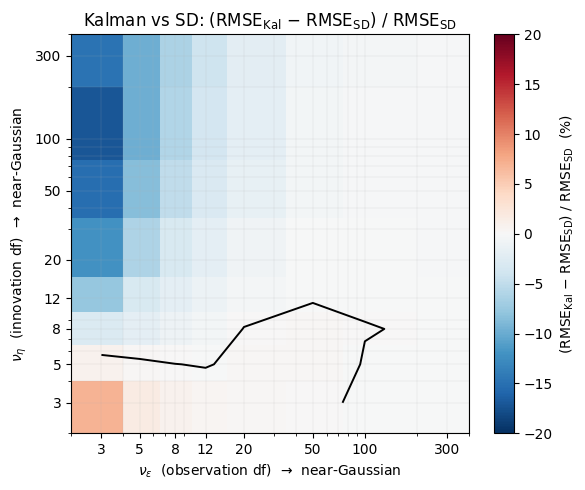

Saved: figs/gaussian_approx_2d_heatmap_kal_vs_sd.png


In [ ]:
# Kalman vs SD comparison
fig_kal_vs_sd = ss.plot_kalman_vs_sd_heatmap(sweep_hpc)
fig_kal_vs_sd.savefig('./figs/gaussian_approx_2d_heatmap_kal_vs_sd.png', dpi=150, bbox_inches='tight')
display(fig_kal_vs_sd)
plt.close('all')
print('Saved: figs/gaussian_approx_2d_heatmap_kal_vs_sd.png')